# 03 · VozSinteticaNet: ¿la voz de la llamada es humana o sintética? (experimental)

**Motivación.** Las estafas telefónicas empiezan a usar voces sintéticas y clonadas (falsos empleados de
banca, falsos familiares). Queremos una señal acústica que complemente al contenido de la llamada.

**Enfoque.** No entrenamos un modelo de audio desde cero (no tenemos datos ni GPU para ello): usamos
**CLAP** (`laion/clap-htsat-unfused`) como extractor de características congelado (embedding de 512
dimensiones) y entrenamos encima una red pequeña en Keras. Es *transfer learning* clásico, como en la
sesión 8 de referencia («After CLIP is CLAP»).

**Rigor experimental.** El riesgo en detección de voz sintética es que el modelo aprenda **atajos**
(calidad de grabación, un sintetizador concreto) en lugar de rasgos generales. Por eso medimos tres cosas:

1. **Dentro de la distribución:** mismos generadores en entrenamiento y test (locutores humanos distintos).
2. **Dejando fuera un generador:** entrenamos con MMS y evaluamos con Bark, y viceversa. Es la pregunta
   importante: ¿detecta sintetizadores que **no ha visto**?
3. **Efecto del canal telefónico:** las mismas pruebas con el audio original y con el audio tras el canal
   telefónico simulado del notebook 01.

**Declaramos desde el principio que es experimental:** en la fusión (notebook 05) esta señal solo puede
**subir** el riesgo, nunca bajarlo.

In [1]:
import json
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from diputado import config

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

from diputado.ai import audio_clap
from diputado.data import voices

config.ensure_ffmpeg_on_path()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Datos (construidos en el notebook 01)

In [2]:
man = voices.build_dataset()
emb = voices.build_embeddings(man)
y = man["label"].values.astype("float32")
gen = man["generador"].values
# Particiones: humanos por split de MLS (locutores disjuntos); sintéticos 70/30 por orden dentro de cada generador.
split = np.where(man["split_origen"] == "dev", "test", "train").astype(object)
for g in ("mms", "bark"):
    idx = np.where(gen == g)[0]
    split[idx[int(0.7 * len(idx)):]] = "test"
man["split"] = split
display(man.groupby(["generador", "split"]).size().unstack())
print({k: v.shape for k, v in emb.items()})

split,test,train
generador,,
bark,24,56
humano,120,160
mms,48,112


{'limpio': (520, 512), 'telefono': (520, 512)}


## 2. Métricas

* **ROC-AUC**, independiente del umbral.
* **EER** (*equal error rate*): punto en el que la tasa de falsos positivos iguala a la de falsos
  negativos. Es la métrica estándar en los retos ASVspoof de detección de voz falsa.

In [3]:
def eer(y_true, score):
    fpr, tpr, thr = roc_curve(y_true, score)
    i = np.nanargmin(np.abs(fpr - (1 - tpr)))
    return float((fpr[i] + 1 - tpr[i]) / 2)


def scores(y_true, s):
    return {"AUC": roc_auc_score(y_true, s), "EER": eer(y_true, s)}

## 3. Referencia: CLAP sin entrenamiento
Usamos la probabilidad que CLAP asigna a la descripción «a robotic synthetic computer generated voice»
frente a las demás descripciones acústicas.

In [4]:
zs = {k: np.array([audio_clap.zero_shot(e)["Voz robótica o sintética"] for e in emb[k]]) for k in ("limpio", "telefono")}
te = man["split"].values == "test"
display(pd.DataFrame({k: scores(y[te], zs[k][te]) for k in zs}).T.round(3))

C:\Users\jdmar\Desktop\Taller Multimodales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,AUC,EER
limpio,0.842,0.25
telefono,0.583,0.45


## 4. Modelos

* **Sonda lineal:** regresión logística sobre el embedding.
* **VozSinteticaNet:** `GaussianNoise(0.03) → Dense(128, GELU) → Dropout(0.4) → Dense(32, GELU) → Dense(1, sigmoide)`.
  El ruido gaussiano sobre el embedding y el *dropout* fuerte son nuestra defensa contra el sobreajuste
  con unos cientos de clips. Ponderamos las clases para que humano y sintético pesen lo mismo.

In [5]:
def build_net(seed=0):
    keras.utils.set_random_seed(seed)
    inp = keras.Input((512,), name="embedding_clap")
    h = keras.layers.GaussianNoise(0.03)(inp)
    h = keras.layers.Dense(128, activation="gelu")(h)
    h = keras.layers.Dropout(0.4)(h)
    h = keras.layers.Dense(32, activation="gelu")(h)
    out = keras.layers.Dense(1, activation="sigmoid", name="voz_sintetica")(h)
    m = keras.Model(inp, out, name="VozSinteticaNet")
    m.compile(optimizer=keras.optimizers.AdamW(2e-3, weight_decay=1e-3), loss="binary_crossentropy")
    return m


def fit_net(Xtr, ytr, seed=0, epochs=150):
    m = build_net(seed)
    w = {0: len(ytr) / (2 * (ytr == 0).sum()), 1: len(ytr) / (2 * (ytr == 1).sum())}
    # Validación interna aleatoria (10 %) solo para la parada temprana.
    rng = np.random.default_rng(seed)
    v = rng.random(len(ytr)) < 0.1
    m.fit(Xtr[~v], ytr[~v], validation_data=(Xtr[v], ytr[v]), epochs=epochs, batch_size=64, verbose=0, class_weight=w,
          callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])
    return m


def run(protocol, key, train_mask, test_mask, seeds=3):
    X = emb[key]
    lr = LogisticRegression(C=1.0, max_iter=3000, class_weight="balanced").fit(X[train_mask], y[train_mask])
    row_lr = {"protocolo": protocol, "audio": key, "modelo": "Sonda lineal", **scores(y[test_mask], lr.predict_proba(X[test_mask])[:, 1])}
    net_scores = [scores(y[test_mask], fit_net(X[train_mask], y[train_mask], seed=s).predict(X[test_mask], verbose=0).ravel())
                  for s in range(seeds)]
    row_net = {"protocolo": protocol, "audio": key, "modelo": "VozSinteticaNet",
               "AUC": np.mean([s["AUC"] for s in net_scores]), "EER": np.mean([s["EER"] for s in net_scores]),
               "AUC_std": np.std([s["AUC"] for s in net_scores])}
    return [row_lr, row_net]

## 5. Experimentos

In [6]:
is_tr, is_te = man["split"].values == "train", man["split"].values == "test"
human, mms, bark = gen == "humano", gen == "mms", gen == "bark"
protocols = {
    "Dentro de distribución (MMS + Bark)": (is_tr, is_te),
    "Entrena MMS → evalúa Bark (no visto)": (is_tr & (human | mms), is_te & (human | bark)),
    "Entrena Bark → evalúa MMS (no visto)": (is_tr & (human | bark), is_te & (human | mms)),
}
t0 = time.perf_counter()
rows = []
for name, (trm, tem) in protocols.items():
    for key in ("limpio", "telefono"):
        rows += run(name, key, trm, tem)
res = pd.DataFrame(rows)
print(f"{len(rows)} experimentos en {time.perf_counter() - t0:.0f} s")
display(res.pivot_table(index=["protocolo", "modelo"], columns="audio", values=["AUC", "EER"]).round(3))

12 experimentos en 399 s


AUC             EER  \
audio                                                limpio telefono limpio   
protocolo                            modelo                                   
Dentro de distribución (MMS + Bark)  Sonda lineal     0.999    0.909  0.008   
                                     VozSinteticaNet  0.999    0.962  0.008   
Entrena Bark → evalúa MMS (no visto) Sonda lineal     0.985    0.776  0.042   
                                     VozSinteticaNet  0.995    0.704  0.025   
Entrena MMS → evalúa Bark (no visto) Sonda lineal     0.966    0.715  0.100   
                                     VozSinteticaNet  0.985    0.731  0.069   

                                                               
audio                                                telefono  
protocolo                            modelo                    
Dentro de distribución (MMS + Bark)  Sonda lineal       0.162  
                                     VozSinteticaNet    0.135  
Entrena Bark → evalúa MMS (no visto) Sonda lineal       0.321  
                                     VozSinteticaNet    0.369  
Entrena MMS → evalúa Bark (no visto) Sonda lineal       0.292  
                                     VozSinteticaNet    0.288

### Cruce de condiciones: entrenar con audio limpio y evaluar en el teléfono
Si el modelo hubiera aprendido rasgos de la voz sintética (y no de la grabación), debería sobrevivir al
cambio de canal.

In [7]:
Xc, Xp = emb["limpio"], emb["telefono"]
cross = []
for s in range(3):
    m = fit_net(Xc[is_tr], y[is_tr], seed=s)
    cross.append(scores(y[is_te], m.predict(Xp[is_te], verbose=0).ravel()))
cross = pd.DataFrame(cross).agg(["mean", "std"])
display(Markdown("**Entrenado con audio limpio, evaluado tras el canal telefónico:**"))
display(cross.round(3))

**Entrenado con audio limpio, evaluado tras el canal telefónico:**

,AUC,EER
mean,0.911,0.169
std,0.006,0.011


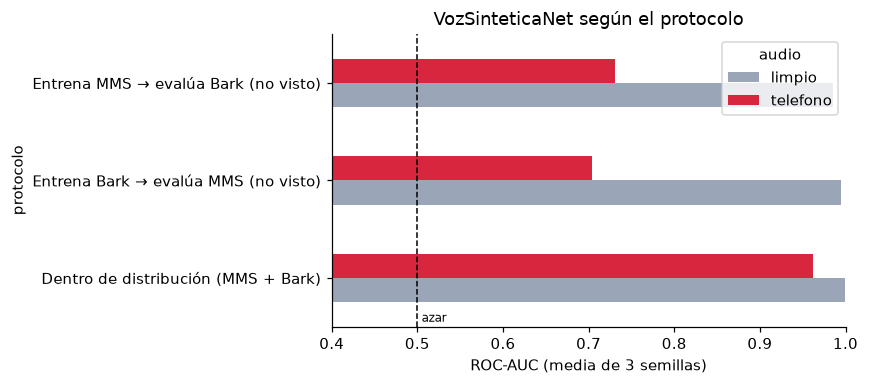

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
plot = res[res["modelo"] == "VozSinteticaNet"].pivot(index="protocolo", columns="audio", values="AUC")
plot.plot.barh(ax=ax, color=["#9aa5b8", "#d7263d"])
ax.axvline(0.5, ls="--", c="k", lw=1); ax.text(0.505, -0.45, "azar", fontsize=8)
ax.set_xlim(0.4, 1.0); ax.set_xlabel("ROC-AUC (media de 3 semillas)"); ax.set_title("VozSinteticaNet según el protocolo")
plt.tight_layout()

## 6. Modelo final y umbral

Entrenamos con **todo el entrenamiento** (humanos de `1_hours`, MMS y Bark) en la versión **telefónica**,
que es la condición de uso real. El umbral lo fijamos para que, en el test, como máximo un 10 % de las
voces humanas se marque como sintética: preferimos perder alguna voz sintética a acusar a un humano.

Test (teléfono): AUC 0.960 · EER 0.121 · umbral 0.484 → TPR 0.86 con FPR 0.10


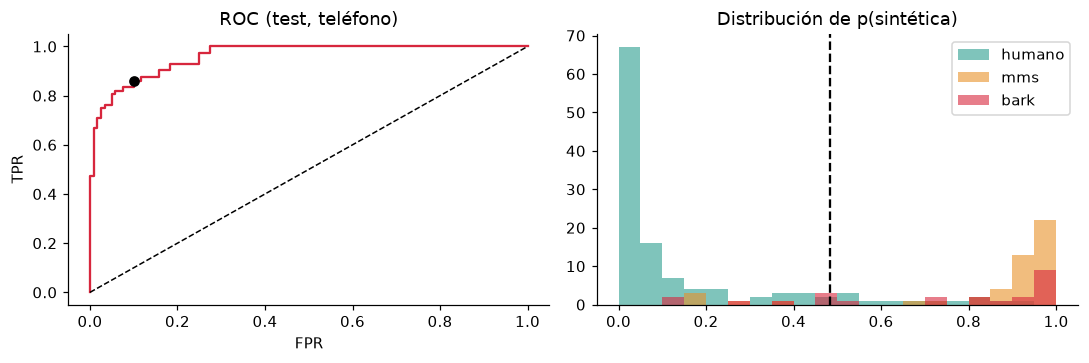

In [9]:
final = fit_net(Xp[is_tr], y[is_tr], seed=0)
p_te = final.predict(Xp[is_te], verbose=0).ravel()
fpr, tpr, thr = roc_curve(y[is_te], p_te)
ok = np.where(fpr <= 0.10)[0][-1]
threshold = float(np.clip(thr[ok], 0.05, 0.95))
final_scores = scores(y[is_te], p_te)
print(f"Test (teléfono): AUC {final_scores['AUC']:.3f} · EER {final_scores['EER']:.3f} · umbral {threshold:.3f} "
      f"→ TPR {tpr[ok]:.2f} con FPR {fpr[ok]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(fpr, tpr, c="#d7263d"); axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].scatter([fpr[ok]], [tpr[ok]], c="k", zorder=3); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC (test, teléfono)")
for g, col in [("humano", "#2a9d8f"), ("mms", "#e89128"), ("bark", "#d7263d")]:
    axes[1].hist(p_te[gen[is_te] == g], bins=20, alpha=0.6, label=g, color=col, range=(0, 1))
axes[1].axvline(threshold, c="k", ls="--"); axes[1].legend(); axes[1].set_title("Distribución de p(sintética)")
plt.tight_layout()

## 7. La llamada de la demo

In [10]:
call = config.DEMO_DIR / "llamada_falso_banco.wav"
a = audio_clap.load(call)
e_call = audio_clap.embed_audio(a)
p_call = float(final.predict(e_call[None], verbose=0).ravel()[0])
print(f"p(voz sintética) de la llamada de la demo (Bark + canal telefónico): {p_call:.2f}")

p(voz sintética) de la llamada de la demo (Bark + canal telefónico): 0.18


## 8. Exportación

In [11]:
final.save(config.ARTIFACTS_DIR / "voz_sintetica.keras")
summary = res.round(4).to_dict(orient="records")
meta = {"threshold": threshold, "embedding": config.HF_MODELS["clap"]["id"], "audio": "canal telefónico simulado",
        "test": {k: round(v, 4) for k, v in final_scores.items()}, "experimentos": summary,
        "cruce_limpio_a_telefono": cross.round(4).to_dict(), "demo_call_p": round(p_call, 4),
        "aviso": "Experimental: solo dos sintetizadores y voz leída. En la fusión solo puede subir el riesgo."}
(config.ARTIFACTS_DIR / "voz_sintetica.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

from diputado.ai import keras_heads

keras_heads._load.cache_clear()
print("Recargado desde la app:", keras_heads.predict_voice(e_call))

Recargado desde la app: {'synthetic_prob': 0.18065153062343597, 'threshold': 0.484017938375473, 'model': 'VozSinteticaNet (Keras)'}


## Conclusiones y limitaciones (honestas)

* **Dentro de la distribución** el problema es casi trivial con embeddings CLAP: los generadores dejan
  huellas muy claras. Esto **no** demuestra que el detector funcione en el mundo real.
* **Dejando fuera un generador** el rendimiento cae: es la medida honesta de generalización y la que
  debería reportar cualquier detector de voz sintética.
* El **canal telefónico** reduce la ventaja del atajo de calidad de grabación; entrenamos y usamos el
  modelo en esa condición.
* Limitaciones: solo dos sintetizadores, voz humana leída (no conversacional), y no evaluamos clonación de
  voz de última generación. Por eso la fusión trata esta señal como **amplificador**: puede subir el
  riesgo cuando la voz parece sintética, pero una voz natural nunca hace que una llamada que pide el PIN
  parezca segura.